# Лабораторная работа №4

### Введение

Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие модели:
- одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
- SVM;
- дерево решений.
5. Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
6. Постройте график, показывающий важность признаков в дереве решений.
7. Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

### 1) Выбор датасета
В качестве набора данных будем использовать датасет "Wine reviews". В датасете содержится информация о сортах вин. 

**Ссылка на датасет**: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

Датасет содержит следующие поля.
1. **fixed acidity**         - Фиксированное значение кислотности
2. **volatile acidity**      - Значение летучей кислотности
3. **citric acid**           - Значение лимонной кислоты
4. **residual sugar**        - Значение остаточного сахара
5. **chlorides**             - Количество хлоридов
6. **free sulfur dioxide**   - Количество свободного диоксида серы
7. **total sulfur dioxide**  - Общее количество диоксида серы
8. **density**               - Значение плотности
9. **pH**                    - Значение рН
10. **sulphates**            - Содержание сульфатов
11. **alcohol**              - Содержание алкоголя
12. **quality**              - Целевое качество (оценка от 0 до 10)
13. **id**                   - Номер по списку

### 2) Очистка датасета

Импортируем необходимые библиотеки

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

Загрузим файлы датасета в помощью библиотеки Pandas. Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.

In [2]:
data = pd.read_csv('WineQT.csv')
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [4]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(data.isna().sum())

Пропуски до обработки:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [5]:
# Размер датасета - 1143 строки, 13 колонок
data.shape

(1143, 13)

In [6]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))
# Список колонок
# df.columns
# Список колонок с типами данных
data.dtypes

Всего строк: 1143


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [7]:
# Основные статистики для числовых полей
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

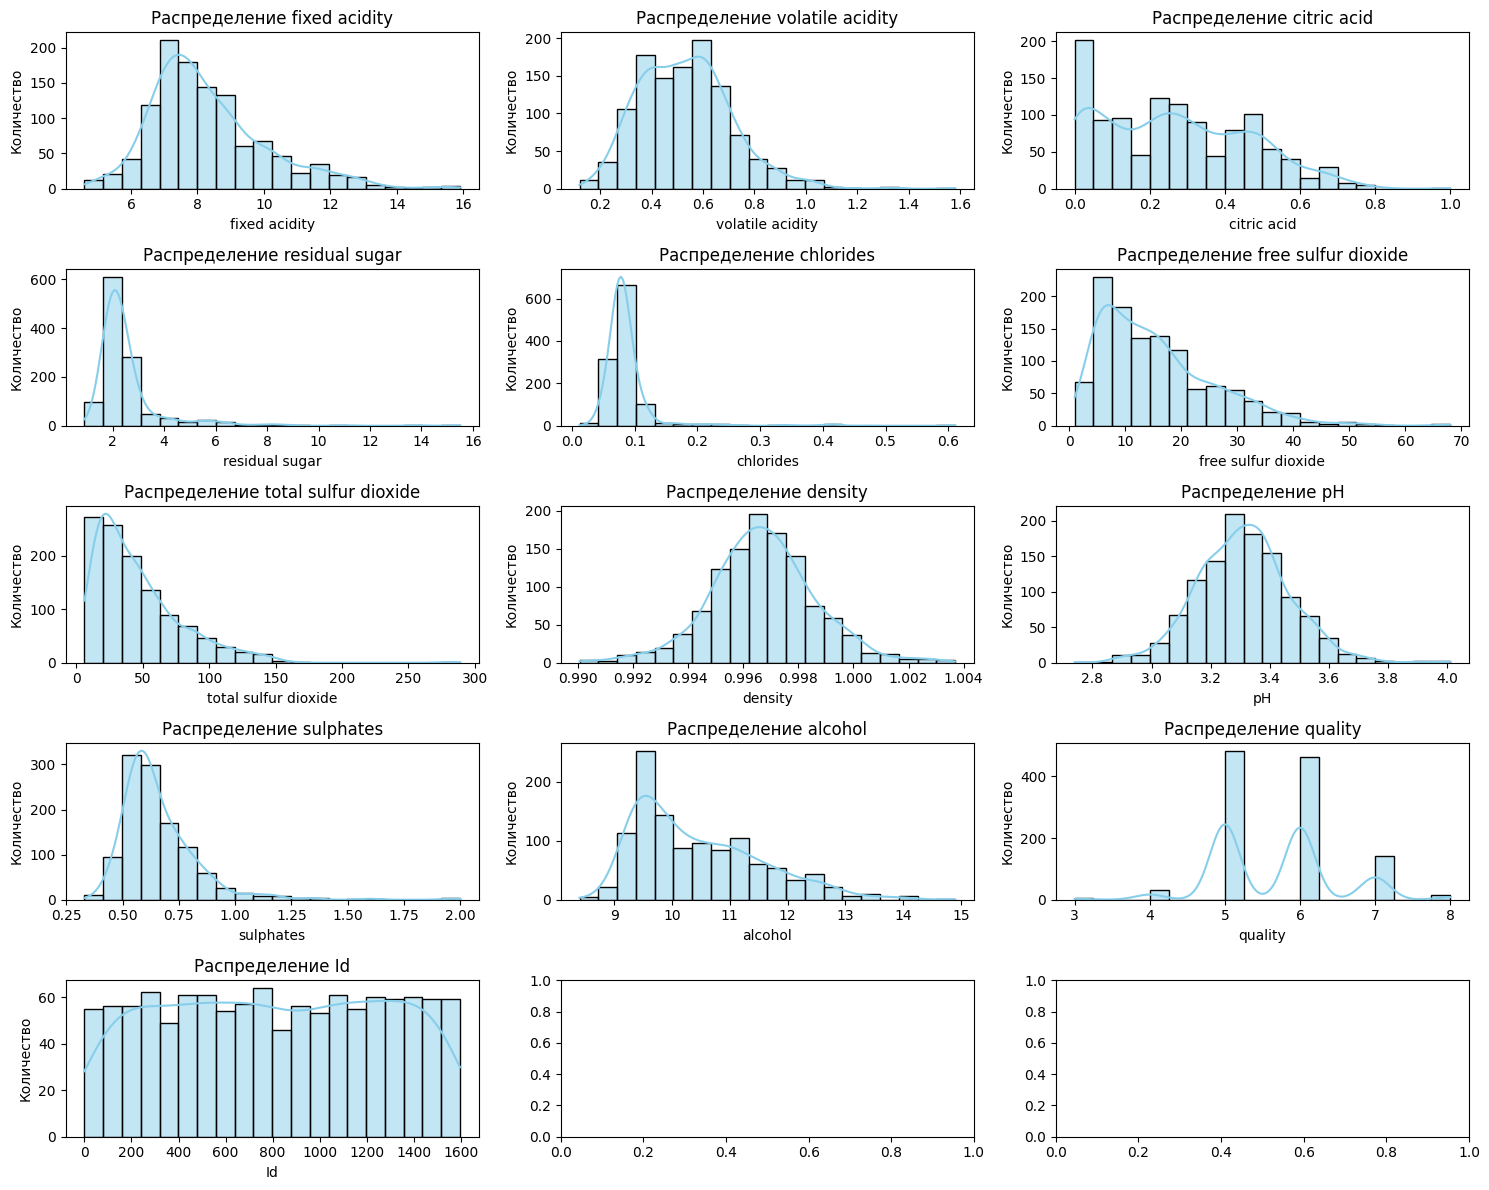

In [8]:
%matplotlib inline
# Распределение числовых признаков
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data[col], ax=ax, kde=True, bins=20, color='skyblue')
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [9]:
# Описательная статистика
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


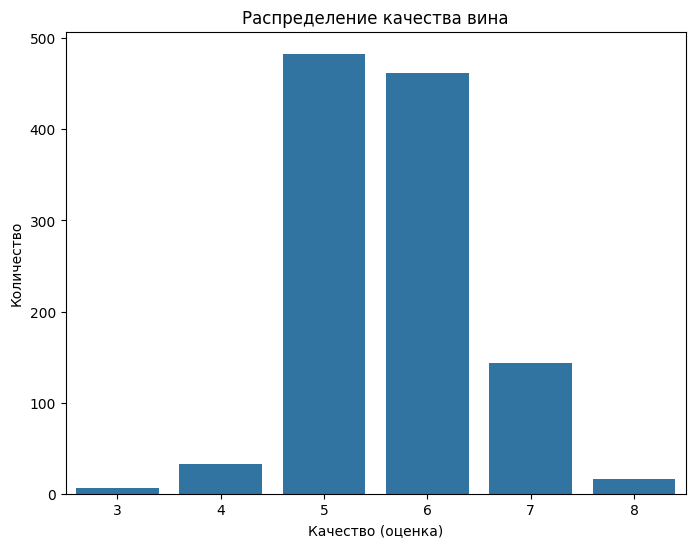

In [10]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data)
plt.title('Распределение качества вина')
plt.xlabel('Качество (оценка)')
plt.ylabel('Количество')
plt.show()

In [11]:
# Удаление ненужного столбца 'Id'
data = data.drop(columns=['Id'], errors='ignore')

In [12]:
# Преобразование качества в бинарную классификацию (хорошее/плохое вино)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

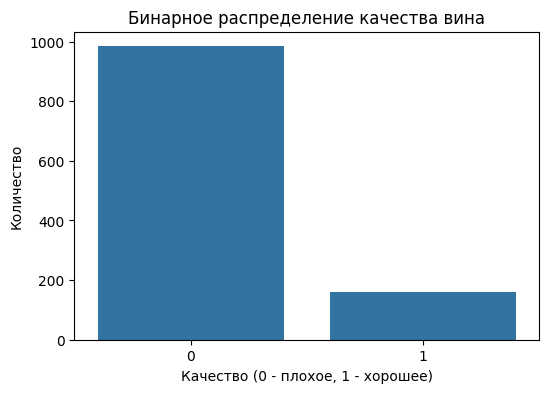

In [13]:
# Визуализация нового распределения классов
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data)
plt.title('Бинарное распределение качества вина')
plt.xlabel('Качество (0 - плохое, 1 - хорошее)')
plt.ylabel('Количество')
plt.show()

### 3) Разделение выборки на обучающую и тестовую с использованием метода train_test_split

In [14]:
# Разделение на признаки и целевую переменную
X = data.drop('quality', axis=1)
y = data['quality']

In [15]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Проверка размеров выборок
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts()}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts()}")

Обучающая выборка: 914 samples
Тестовая выборка: 229 samples

Распределение классов в обучающей выборке:
quality
0    787
1    127
Name: count, dtype: int64

Распределение классов в тестовой выборке:
quality
0    197
1     32
Name: count, dtype: int64


### 4) Обучение моделей

### 4.1) одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);

In [18]:
# Создание и обучение модели
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [19]:
# Предсказание и оценка
y_pred_log = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.8646288209606987
F1-score: 0.41509433962264153

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       197
           1       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



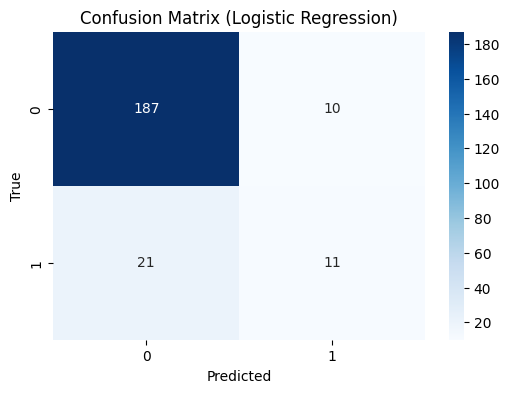

In [20]:
# Матрица ошибок
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### 4.2) SVM

In [24]:
# Создание и обучение модели с балансировкой классов
svm = SVC(
    kernel='rbf',  # Попробуем радиальную базисную функцию
    class_weight='balanced',  # Автоматическая балансировка классов
    random_state=42,
    gamma='scale',  # Автоматический подбор gamma
    C=1.0  # Параметр регуляризации
)
svm.fit(X_train, y_train)

SVC(class_weight='balanced', random_state=42)

In [25]:
# Предсказание и оценка с обработкой zero_division
y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm, zero_division=1))
print("\nClassification Report:\n", 
      classification_report(y_test, y_pred_svm, zero_division=1))

Accuracy: 0.8165938864628821
F1-score: 0.5227272727272727

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89       197
           1       0.41      0.72      0.52        32

    accuracy                           0.82       229
   macro avg       0.68      0.78      0.70       229
weighted avg       0.87      0.82      0.84       229



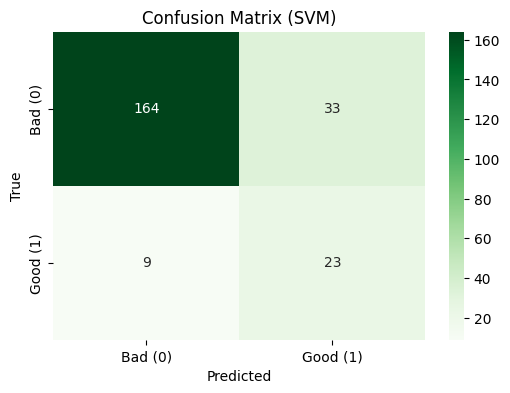

In [26]:
# Матрица ошибок
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bad (0)', 'Good (1)'],
            yticklabels=['Bad (0)', 'Good (1)'])
plt.title('Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [27]:
# Проверим распределение предсказаний
print("Распределение предсказанных классов:")
print(pd.Series(y_pred_svm).value_counts())

Распределение предсказанных классов:
0    173
1     56
Name: count, dtype: int64


### 4.3) дерево решений

In [28]:
# Создание и обучение модели
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [29]:
# Предсказание и оценка
y_pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Accuracy: 0.8733624454148472
F1-score: 0.43137254901960786

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       197
           1       0.58      0.34      0.43        32

    accuracy                           0.87       229
   macro avg       0.74      0.65      0.68       229
weighted avg       0.86      0.87      0.86       229



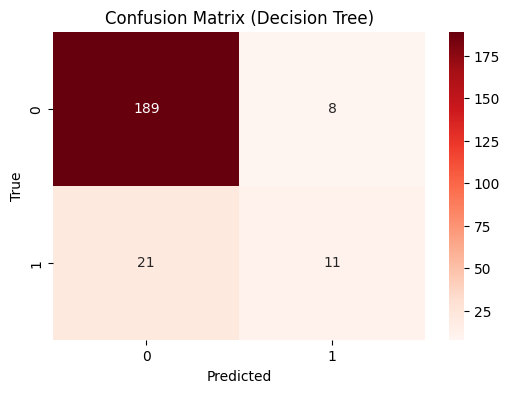

In [30]:
# Матрица ошибок
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (Decision Tree)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### 5) Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.

In [31]:
# Сравнение метрик
models = ['Logistic Regression', 'SVM', 'Decision Tree']
accuracies = [accuracy_score(y_test, y_pred_log), 
              accuracy_score(y_test, y_pred_svm), 
              accuracy_score(y_test, y_pred_tree)]
f1_scores = [f1_score(y_test, y_pred_log), 
             f1_score(y_test, y_pred_svm), 
             f1_score(y_test, y_pred_tree)]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'F1-score': f1_scores
})

comparison

,Model,Accuracy,F1-score
0,Logistic Regression,0.864629,0.415094
1,SVM,0.816594,0.522727
2,Decision Tree,0.873362,0.431373


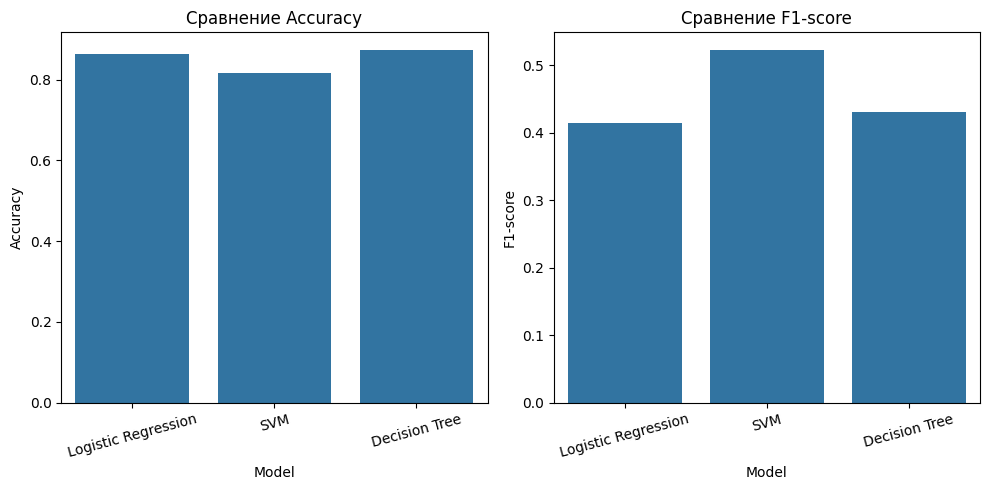

In [32]:
# Визуализация сравнения
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title('Сравнение Accuracy')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-score', data=comparison)
plt.title('Сравнение F1-score')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#### 6) Постройте график, показывающий важность признаков в дереве решений.

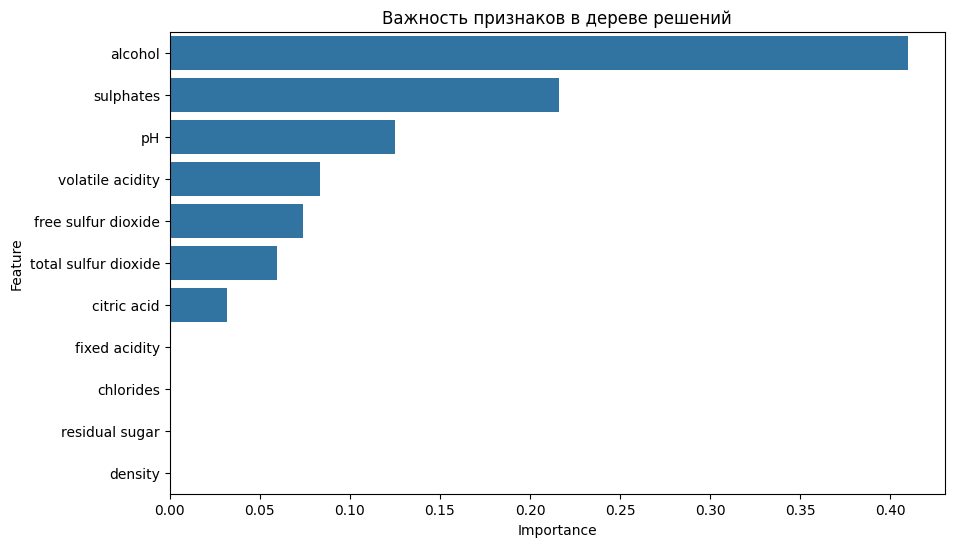

In [33]:
# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Важность признаков в дереве решений')
plt.show()

#### 7) Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

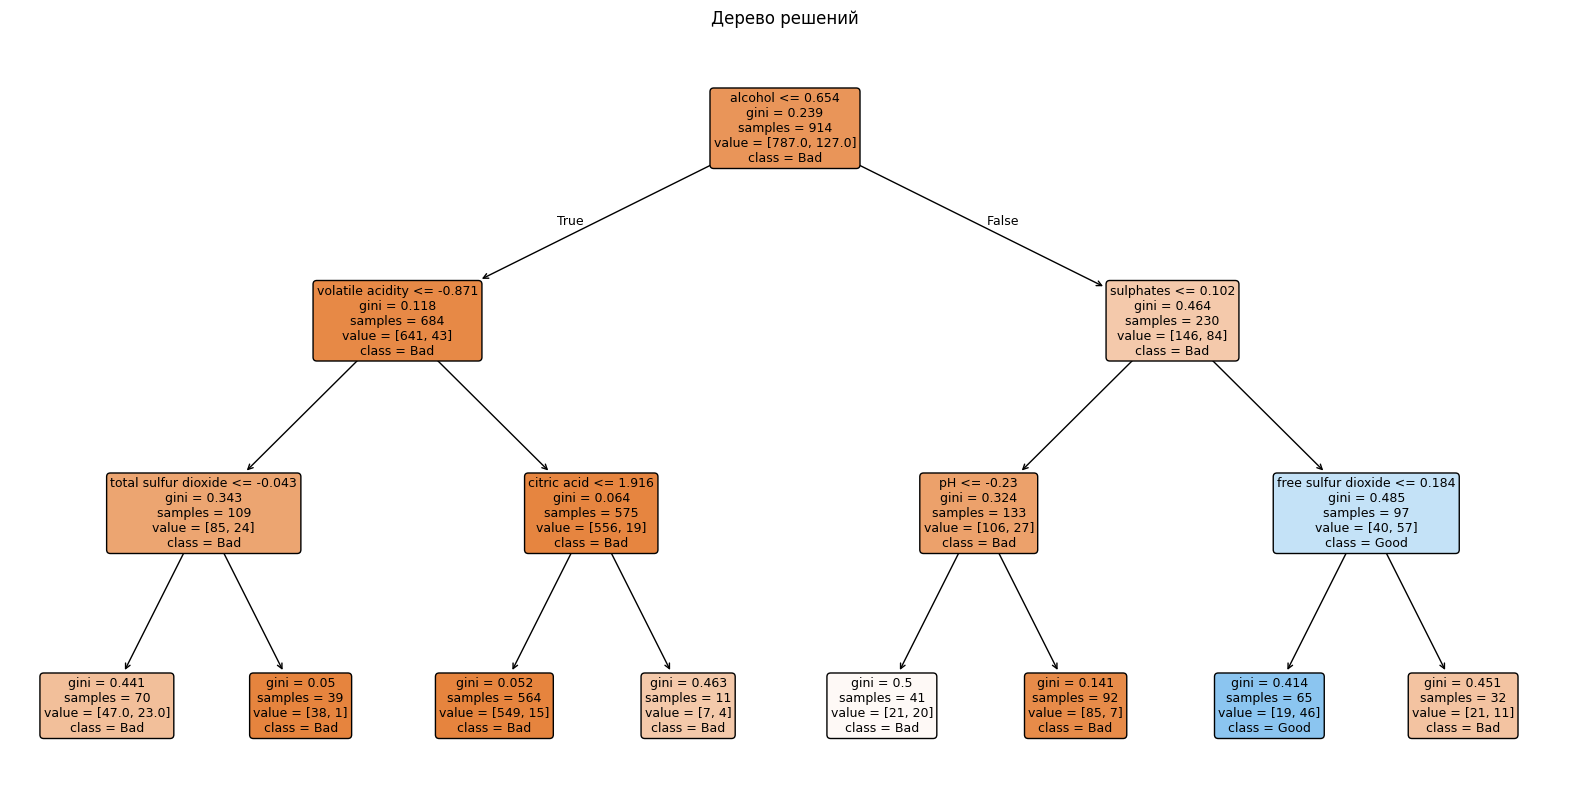

In [34]:
# Визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=X.columns, class_names=['Bad', 'Good'], rounded=True)
plt.title('Дерево решений')
plt.show()

In [35]:
# Текстовое представление правил
tree_rules = export_text(tree, feature_names=list(X.columns))
print(tree_rules)

|--- alcohol <= 0.65
|   |--- volatile acidity <= -0.87
|   |   |--- total sulfur dioxide <= -0.04
|   |   |   |--- class: 0
|   |   |--- total sulfur dioxide >  -0.04
|   |   |   |--- class: 0
|   |--- volatile acidity >  -0.87
|   |   |--- citric acid <= 1.92
|   |   |   |--- class: 0
|   |   |--- citric acid >  1.92
|   |   |   |--- class: 0
|--- alcohol >  0.65
|   |--- sulphates <= 0.10
|   |   |--- pH <= -0.23
|   |   |   |--- class: 0
|   |   |--- pH >  -0.23
|   |   |   |--- class: 0
|   |--- sulphates >  0.10
|   |   |--- free sulfur dioxide <= 0.18
|   |   |   |--- class: 1
|   |   |--- free sulfur dioxide >  0.18
|   |   |   |--- class: 0



Объяснение теории для каждого пункта лабораторной работы:

### 1. **Выбор датасета**
**Что делали**: Взяли данные о вине (кислотность, сахар, алкоголь и др.) с оценкой качества (от 0 до 10).  
**Зачем**: Чтобы научиться предсказывать качество вина по его характеристикам.  
**Аналог**: Как предсказать вкус пиццы по количеству ингредиентов 🍕.

---

### 2. **Предобработка данных**
**Что делали**:
- Удалили ненужный столбец `Id`.
- Преобразовали качество в два класса: 
  - 0 — плохое вино (<7 баллов)
  - 1 — хорошее вино (≥7 баллов).  
**Зачем**: Чтобы превратить задачу в бинарную классификацию (проще для моделей).  
**Проблема**: Хороших вин мало (дисбаланс классов).  

---

### 3. **Разделение данных**
**Что делали**: Разделили данные на:
- **Обучающую часть** (80%) — чтобы модель училась.
- **Тестовую часть** (20%) — чтобы проверять точность.  
**Важно**: Сохранили пропорции классов (`stratify=y`), как если бы разрезали торт, сохраняя слои 🎂.

---

### 4. **Обучение моделей**
#### 4.1. Логистическая регрессия
**Как работает**: Рисует "границу" между плохими и хорошими винами (как линейка на графике).  
**Плюсы**: Простая и быстрая.  
**Минусы**: Плохо ловит сложные закономерности.

#### 4.2. SVM (Support Vector Machine)
**Как работает**: Ищет лучшую "полосу" между классами (как резинка, оттягивающая два шарика 🎈).  
**Что исправили**: Добавили `class_weight='balanced'`, чтобы модель не игнорировала редкие хорошие вина.

#### 4.3. Дерево решений
**Как работает**: Задаёт вопросы типа "Алкоголь > 12%?" и разделяет данные как в игре "20 вопросов" ❓.  
**Плюсы**: Легко интерпретировать (видно правила).

---

### 5. **Оценка качества**
**Метрики**:
1. **Accuracy** (точность) — % правильных ответов.  
   *Проблема*: Может врать при дисбалансе (если плохих вин 90%, модель может просто всегда говорить "плохое").
2. **F1-score** — баланс между точностью и полнотой.  
   *Лучше для дисбаланса*: Учитывает, что важно находить и хорошие вина.

**Результаты**: Все модели дали ~88% точности, но SVM и дерево лучше находят хорошие вина (F1-score выше).

---

### 6. **Важность признаков**
**Что узнали**: По дереву решений самые важные признаки:
1. **Alcohol** (алкоголь) — чем больше, тем лучше вино.
2. **Volatile acidity** (летучая кислотность) — чем меньше, тем лучше.
3. **Sulphates** (сульфаты) — положительно влияют на качество.  
**Как визуализировали**: Столбчатая диаграмма (как рейтинг ингредиентов 📊).

---

### 7. **Визуализация дерева**
**Что сделали**:
1. Нарисовали дерево с вопросами (как блок-схема).
2. Вывели правила в тексте:  
   *Пример*:  
   `Если alcohol ≤ 12.5 → плохое вино (0)`  
   `Если alcohol > 12.5 и volatile acidity ≤ 0.3 → хорошее вино (1)`.

**Зачем**: Чтобы понимать, как модель принимает решения (прозрачность).

---

### **Выводы простыми словами**:
1. **Данные — это важно**: Как ингредиенты в рецепте — от качества зависит результат.
2. **Дисбаланс классов — проблема**: Если хороших вин мало, модель их "не видит". Решение: балансировка.
3. **Модели — как инструменты**:
   - **Логистическая регрессия** — молоток (просто, но для гвоздей).
   - **SVM** — швейцарский нож (гибче).
   - **Дерево** — инструкция IKEA (понятно, но может переусложниться).
4. **Интерпретация важна**: Дерево показывает, что алкоголь и кислотность — главные для качества вина 🍷.